# Colab

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [52]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

In [53]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [54]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [55]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [56]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


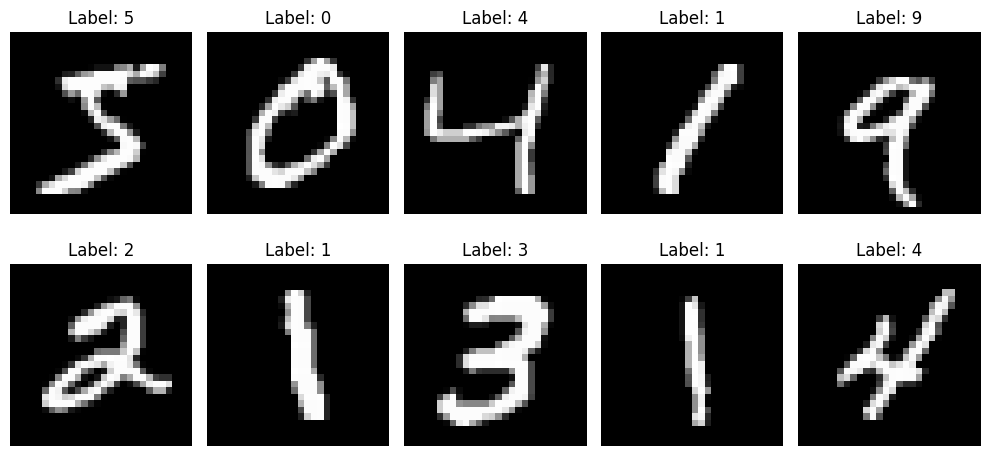

In [57]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
class MNIST_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


Using device: cuda


In [11]:
model = MNIST_CNN().to(device)

print(model)


MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [12]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)

Total parameters: 421642


In [13]:
criterion = nn.CrossEntropyLoss()

In [14]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [15]:
epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.1348 Accuracy: 95.88%
Epoch [2/5] Loss: 0.0421 Accuracy: 98.69%
Epoch [3/5] Loss: 0.0279 Accuracy: 99.06%
Epoch [4/5] Loss: 0.0205 Accuracy: 99.29%
Epoch [5/5] Loss: 0.0149 Accuracy: 99.49%


In [16]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 99.08%


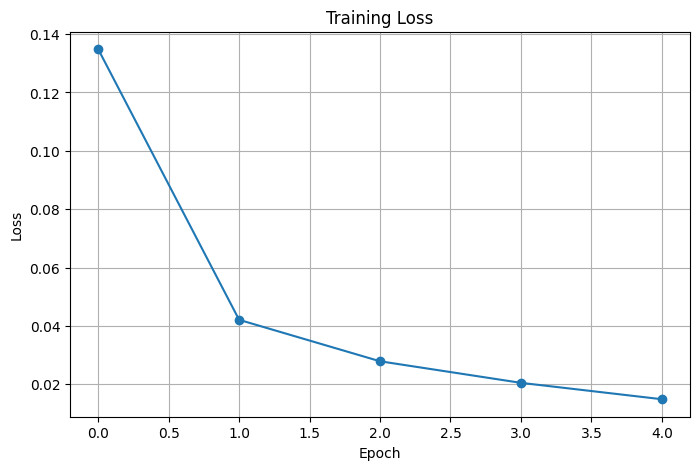

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

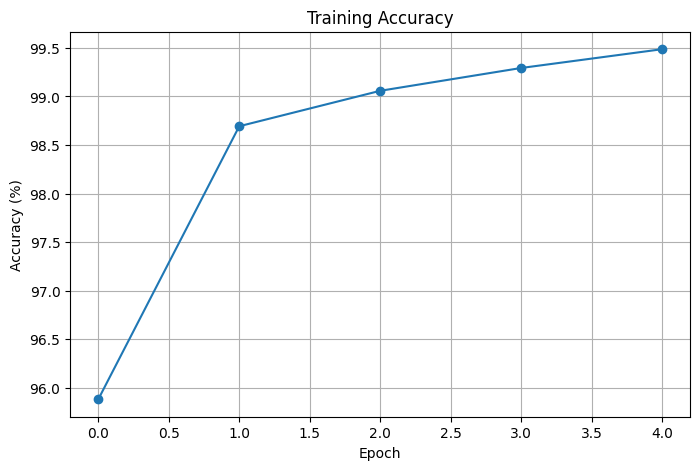

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()
plt.show()

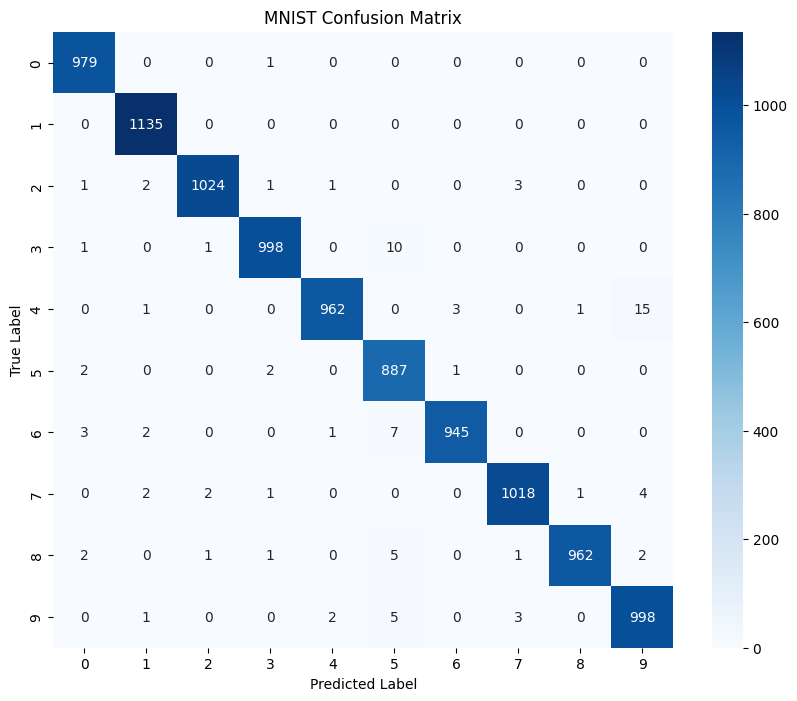

In [19]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

plt.show()

In [20]:
print(
    classification_report(
        all_labels,
        all_predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [21]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    _, predictions = torch.max(
        outputs,
        1
    )

images = images.cpu()
predictions = predictions.cpu()
labels = labels

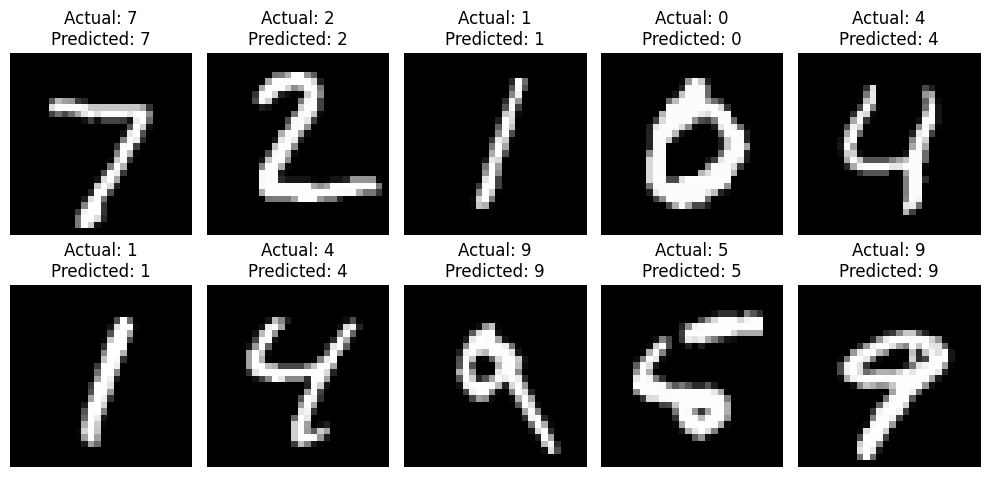

In [22]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(10, 5)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"Actual: {labels[i]}\n"
        f"Predicted: {predictions[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
wrong_indices = np.where(
    np.array(all_predictions)
    != np.array(all_labels)
)[0]

print(
    "Number of wrong predictions:",
    len(wrong_indices)
)

Number of wrong predictions: 92


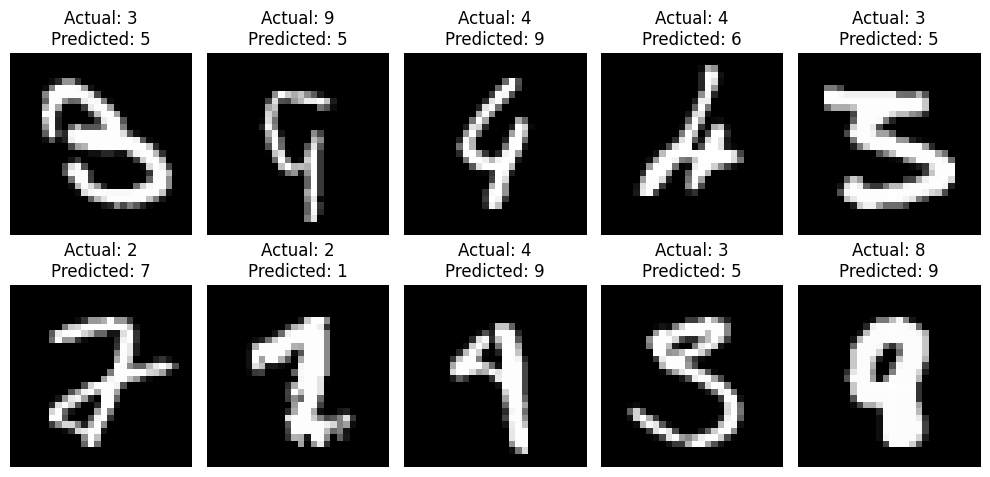

In [24]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(10, 5)
)

for i, ax in enumerate(axes.flat):

    idx = wrong_indices[i]

    image, label = test_dataset[idx]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"Actual: {label}\n"
        f"Predicted: {all_predictions[idx]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# **Predict single img**

In [44]:
def predict_digit(
    model,
    dataset,
    index
):

    model.eval()

    image, label = dataset[index]

    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_input)

        prediction = torch.argmax(
            output,
            dim=1
        ).item()

    plt.figure(figsize=(4, 4))

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {label} | "
        f"Predicted: {prediction}"
    )

    plt.axis("off")
    plt.show()

    return prediction

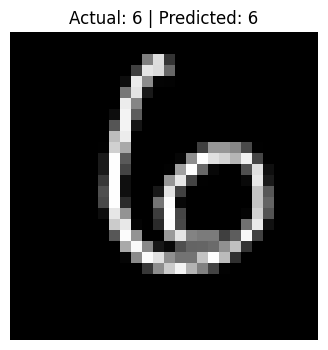

6

In [45]:
predict_digit(
    model,
    test_dataset,
    100
)

# **Save the model**

In [46]:
torch.save(
    model.state_dict(),
    "mnist_cnn.pth"
)

# **Load model**

In [28]:
loaded_model = MNIST_CNN().to(device)

loaded_model.load_state_dict(
    torch.load(
        "mnist_cnn.pth",
        map_location=device
    )
)

loaded_model.eval()

MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)